In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
data = pd.read_csv('marketing_sales_data.csv')
data = data.dropna()
data.columns = data.columns.str.strip().str.replace('', '_')
print("--- Cleaned Data Columns ---")
print(data.columns)
print("\n--- Initial Rows---")
print(data.head())

--- Cleaned Data Columns ---
Index(['_T_V_', '_R_a_d_i_o_', '_S_o_c_i_a_l___M_e_d_i_a_', '_S_a_l_e_s_'], dtype='str')

--- Initial Rows---
   _T_V_  _R_a_d_i_o_  _S_o_c_i_a_l___M_e_d_i_a_  _S_a_l_e_s_
0   16.0     6.566231                   2.907983    54.732757
1   13.0     9.237765                   2.409567    46.677897
2   41.0    15.886446                   2.913410   150.177829
3   83.0    30.020028                   6.922304   298.246340
4   15.0     8.437408                   1.405998    56.594181


--- Channel Correlation Coefficients with Sales---
Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


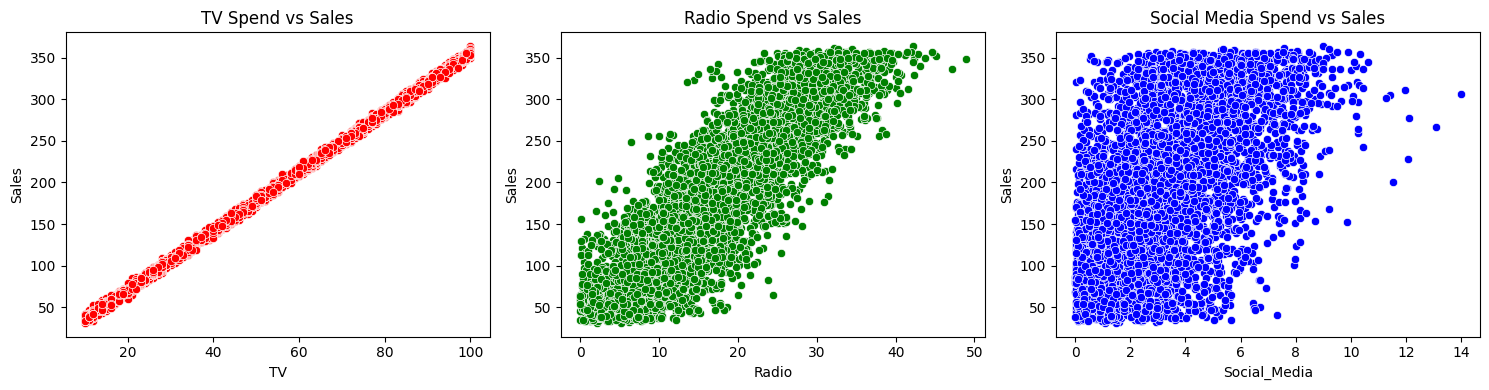

In [4]:
data.columns = ['TV', 'Radio', 'Social_Media', 'Sales']
correlation_results = data.corr(numeric_only=True)
print("--- Channel Correlation Coefficients with Sales---")
print(correlation_results["Sales"].sort_values(ascending=False))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=data, x="TV", y="Sales", ax=axes[0], color="red")
axes[0].set_title("TV Spend vs Sales")
sns.scatterplot(data=data, x="Radio", y="Sales", ax=axes[1], color="green")
axes[1].set_title("Radio Spend vs Sales")
sns.scatterplot(data=data, x="Social_Media", y="Sales", ax=axes[2], color="blue")
axes[2].set_title("Social Media Spend vs Sales")
plt.tight_layout()
plt.show()

In [5]:
import statsmodels.api as sm
X = data['TV']
Y = data['Sales']
X = sm.add_constant(X)
slr_model = sm.OLS(Y, X).fit()
print("--- Simple Linear Regression Results ---")
print(slr_model.summary())

--- Simple Linear Regression Results ---
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:14:58   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

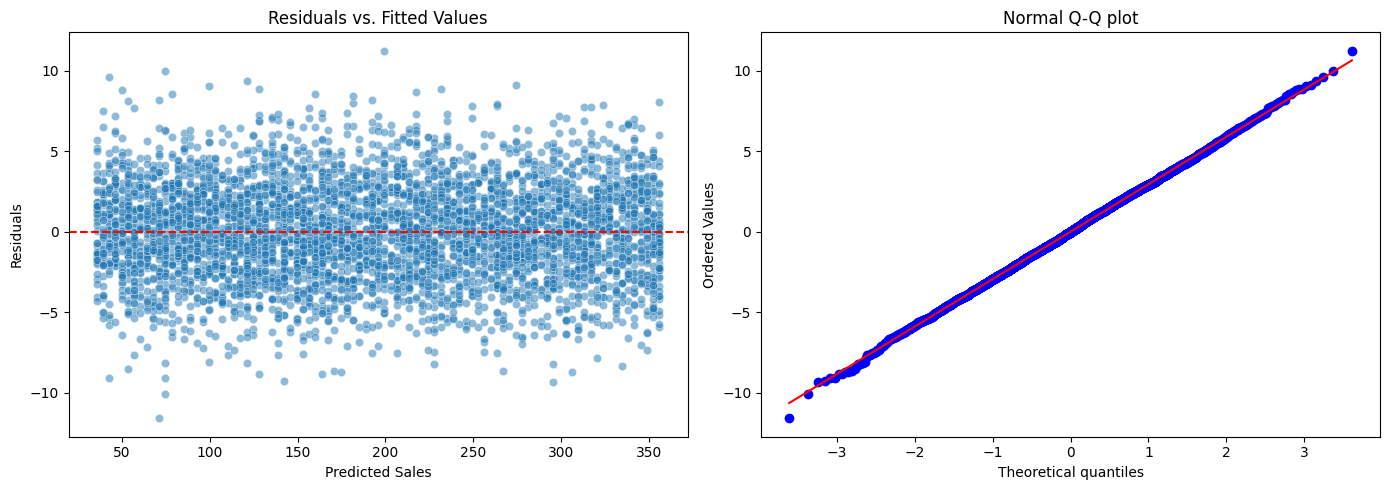

In [6]:
import scipy.stats as stats
residuals = slr_model.resid
fitted_values = slr_model.fittedvalues
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted Values')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals')
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Normal Q-Q plot')
plt.tight_layout()
plt.show()

## Statistical Analysis & Business Interpretations
### 1. Variable Selection Justification
- **Finding:** TV advertising shares an exceptionally strong linear correlation of **0.9995** with sales, outperforming all other media channels.
- **Decision:** TV was selected as the optimal independent variable for our  baseline model.
### 2. Stakeholder Model Evaluation
- **R-squared (0.999):** Exactly **99.9%** of all variance in Sales is explained directly by adjustments to our TV advertising budget.
- **P-value (0.000):** The TV channel predictor is highly statistically significant, confirming this relationship is completly reliable.
### 3. Formal Regression Equation
Based on our model coefficients(intercept $\beta_0 = -0.1325$, TV Slope $\beta_1 = 3.5615$),  our formal linear regression equation is:
$$\text{Sales} = 3.5615 \times\text{TV} -0.1325$$
### 4. Verification of Assumptions
- **Linearity & Homoscedasticity:** The Residuals vs. Fitted plot displays a balanced, uniform distribution f error terms across the center zero-line, confirming constant variance.
- **Normality:** The normal Q-Q plot exhibits a tight , linear distribution hugging the reference line, proving error normality.
### 5. Business Recommendation
Every additional $1,000 unit  spent on TV advertising returns an average increase of **$3,561.50** in Sales.Marketing leadership should prioritize scaling budgets toward TV ad campaigns due to its near-perfect revenue predictability.